In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path

notebook_path = "/u/skarmakar1/version_check/llm_steering-main/sk"
sys.path.append(notebook_path)

In [3]:
import torch
import numpy as np

from inversion_utils import *
import pickle
from sklearn.model_selection import train_test_split

In [4]:
SEED = 0
# SEED = 1

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

torch.backends.cudnn.benchmark = True 
torch.backends.cuda.matmul.allow_tf32 = True

LLM = namedtuple('LLM', ['language_model', 'tokenizer', 'processor', 'name', 'model_type'])

In [5]:
# model_type = 'llama'
# MODEL_VERSION='3.1'
# MODEL_SIZE='8B'

# model_type = 'gemma'
# MODEL_VERSION='3'
# MODEL_SIZE='1B'
# MODEL_SIZE='12B'

model_type = 'qwen'
MODEL_VERSION='3'
MODEL_SIZE='4B'
# MODEL_SIZE='8B'

llm = select_llm(model_type, MODEL_VERSION=MODEL_VERSION, MODEL_SIZE=MODEL_SIZE)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [6]:
hidden_layers = list(range(-1, -llm.language_model.config.num_hidden_layers, -1))
print(hidden_layers)

[-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31, -32, -33, -34, -35]


Training

In [6]:
categories = ["physical", "texture", "time", "complexity", "logic", "state", "social"]
antonym_pairs = []

for category in categories:
    with open(f"../data/adjectives/{category}_antonym_pairs.pkl", 'rb') as file:
        antonyms = pickle.load(file)
    
    for p in antonyms:
        antonym_pairs.append(tuple([p[0].lower(), p[1].lower(), category]))

In [7]:
print(antonym_pairs[:5])

[('big', 'small', 'physical'), ('wide', 'narrow', 'physical'), ('thick', 'thin', 'physical'), ('tall', 'short', 'physical'), ('deep', 'shallow', 'physical')]


In [8]:
test_size = 0.1

print("Total data:", len(antonym_pairs))
print(antonym_pairs[:5])

train_data_t, test_data = train_test_split(antonym_pairs, test_size=test_size, random_state=SEED)

print("Training data normal:", len(train_data_t))
print(train_data_t[:5])

swap_train_data = [(b, a, c) for a, b, c in train_data_t]
print("Training data swapped:", len(swap_train_data))
print(swap_train_data[:5])

train_data = train_data_t + swap_train_data
print("Training data:", len(train_data))
print(train_data[:5])

print("Testing data:", len(test_data))
print(test_data[:5])

# t1_list = [tuple(item.lower() for item in tpl) for tpl in train_data]
# t2_list = [tuple(item.lower() for item in tpl) for tpl in test_data]

# train_data = t1_list
# test_data = t2_list

Total data: 740
[('big', 'small', 'physical'), ('wide', 'narrow', 'physical'), ('thick', 'thin', 'physical'), ('tall', 'short', 'physical'), ('deep', 'shallow', 'physical')]
Training data normal: 666
[('hard', 'soft', 'texture'), ('fair-minded', 'biased', 'social'), ('probable', 'improbable', 'logic'), ('pregnant', 'barren', 'state'), ('punishing', 'forgiving', 'complexity')]
Training data swapped: 666
[('soft', 'hard', 'texture'), ('biased', 'fair-minded', 'social'), ('improbable', 'probable', 'logic'), ('barren', 'pregnant', 'state'), ('forgiving', 'punishing', 'complexity')]
Training data: 1332
[('hard', 'soft', 'texture'), ('fair-minded', 'biased', 'social'), ('probable', 'improbable', 'logic'), ('pregnant', 'barren', 'state'), ('punishing', 'forgiving', 'complexity')]
Testing data: 74
[('itchy', 'relieved', 'texture'), ('colorful', 'colorless', 'texture'), ('expansive', 'confined', 'physical'), ('fat', 'skinny', 'physical'), ('sympathetic', 'unsympathetic', 'social')]


In [9]:
print(test_data)

[('itchy', 'relieved', 'texture'), ('colorful', 'colorless', 'texture'), ('expansive', 'confined', 'physical'), ('fat', 'skinny', 'physical'), ('sympathetic', 'unsympathetic', 'social'), ('kind', 'cruel', 'social'), ('dynamic', 'stagnant', 'time'), ('just', 'unjust', 'social'), ('clever', 'clumsy', 'logic'), ('towering', 'squat', 'physical'), ('perpendicular', 'parallel', 'physical'), ('precise', 'inaccurate', 'complexity'), ('solid', 'hollow', 'physical'), ('rotten', 'ripe', 'texture'), ('agonizing', 'soothing', 'texture'), ('squeaky', 'deep', 'texture'), ('valid', 'void', 'state'), ('incompetent', 'competent', 'complexity'), ('friendly', 'unfriendly', 'social'), ('clean', 'dirty', 'physical'), ('continuous', 'sporadic', 'time'), ('polite', 'rude', 'social'), ('virgin', 'used', 'time'), ('scented', 'odorless', 'texture'), ('amateurish', 'professional', 'complexity'), ('knotty', 'smooth', 'complexity'), ('early', 'late', 'time'), ('developing', 'declining', 'time'), ('brave', 'cowardly

In [10]:
X_train, Y_train = read_tuples_with_category(llm, train_data, path='../all_gitignore/directions_adjectives_llama/{}/')
X_test, Y_test = read_tuples_with_category(llm, test_data, path='../all_gitignore/directions_adjectives_llama/{}/')

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

D

In [11]:
# lrr_models = LRR_auto(X_train, Y_train)

In [12]:
# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_models.pkl', 'wb') as file:
#     pickle.dump(lrr_models, file)

In [13]:
# All layers in one

In [14]:
print(X_train[-1].shape)
print(Y_train[-1].shape)

torch.Size([1332, 4096])
torch.Size([1332, 4096])


In [15]:
big_X = torch.vstack(list(X_train.values())).cpu().numpy()
big_Y = torch.vstack(list(Y_train.values())).cpu().numpy()

print(big_X.shape)
print(big_Y.shape)

(41292, 4096)
(41292, 4096)


In [16]:
from sklearn.utils import shuffle

big_X_shuffled, big_Y_shuffled = shuffle(big_X, big_Y, random_state=SEED)

In [17]:
flag = 0
print_error = True
# x = X[i].cpu().numpy()
# y = Y[i].cpu().numpy()

if flag == 1:
    alpha=10000.0
    reg_lrr = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver='cholesky'))

elif flag == 0:
    alphas = 10.0 ** np.arange(2, 6)  # log grid
    print(f"Running with alpha: {alphas}")
    reg_lrr = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=10))

model_lrr = TransformedTargetRegressor(regressor=reg_lrr, transformer=StandardScaler())

model_lrr.fit(big_X_shuffled, big_Y_shuffled)

if flag == 0:
    best_alpha_lrr = model_lrr.regressor_.named_steps["ridgecv"].alpha_
    print(f"Best lambda: {best_alpha_lrr}")

if print_error:
    y_pred = model_lrr.predict(big_X_shuffled)
    mse = mean_squared_error(big_Y_shuffled, y_pred)
    rmse = np.sqrt(mse)

    r2 = r2_score(big_Y_shuffled, y_pred)

    print(f"Training RMSE: {rmse:.4f}, Training R2: {r2:.4f}")

# xtx = x.T @ x
# A = torch.linalg.solve(xtx + lambda_reg * torch.eye(d).to("cuda"), x.T @ y) # switch to more robust

print(f"Done.")

# lrr_models[i] = model_lrr

Running with alpha: [   100.   1000.  10000. 100000.]
Best lambda: 1000.0
Training RMSE: 0.0073, Training R2: 0.7546
Done.


In [20]:
lrr_models = {i: model_lrr for i in hidden_layers}

In [ ]:
# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_all_layers_models.pkl', 'wb') as file:
#     pickle.dump(lrr_models, file)

In [23]:
layer = -15
weight_t, bias_t = get_W_b(lrr_models[layer])
va1, ve1 = eig(weight_t)

In [24]:
va1_mag = sorted(np.abs(va1), reverse=True)
va1_real = sorted([i.real for i in va1], reverse=True)
va1_imag = sorted([i.imag for i in va1], reverse=True)

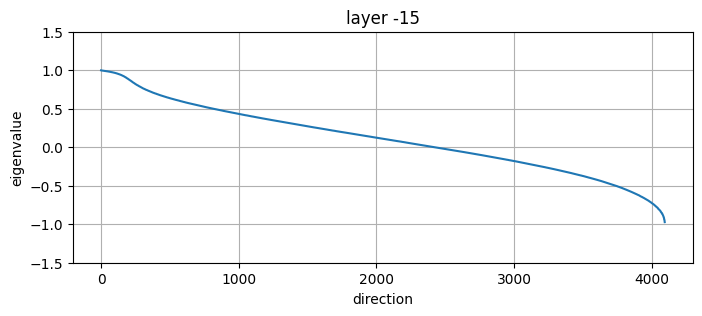

In [28]:
plt.figure(figsize=(8, 3))

plt.plot(va1_real)
# plt.plot(va1_imag)
# plt.plot(va1_mag)

plt.ylim(-1.5, 1.5)
# plt.xlim(0, 500)
plt.title(f"layer {layer}")
plt.xlabel("direction")
plt.ylabel("eigenvalue")
plt.grid(True)
plt.show()

Testing

In [ ]:
# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_models.pkl', 'rb') as file:
with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_all_layers_models.pkl', 'rb') as file:
    lrr_models = pickle.load(file)

In [ ]:
# [('itchy', 'relieved', 'texture'), ('colorful', 'colorless', 'texture'), ('expansive', 'confined', 'physical'), ('fat', 'skinny', 'physical'), ('sympathetic', 'unsympathetic', 'social'), ('kind', 'cruel', 'social'), ('dynamic', 'stagnant', 'time'), ('just', 'unjust', 'social'), ('clever', 'clumsy', 'logic'), ('towering', 'squat', 'physical'), ('perpendicular', 'parallel', 'physical'), ('precise', 'inaccurate', 'complexity'), ('solid', 'hollow', 'physical'), ('rotten', 'ripe', 'texture'), ('agonizing', 'soothing', 'texture'), ('squeaky', 'deep', 'texture'), ('valid', 'void', 'state'), ('incompetent', 'competent', 'complexity'), ('friendly', 'unfriendly', 'social'), ('clean', 'dirty', 'physical'), ('continuous', 'sporadic', 'time'), ('polite', 'rude', 'social'), ('virgin', 'used', 'time'), ('scented', 'odorless', 'texture'), ('amateurish', 'professional', 'complexity'), ('knotty', 'smooth', 'complexity'), ('early', 'late', 'time'), ('developing', 'declining', 'time'), ('brave', 'cowardly', 'social'), ('right', 'wrong', 'logic'), ('huge', 'tiny', 'physical'), ('good', 'evil', 'social'), ('serene', 'agitated', 'social'), ('harmonious', 'grating', 'texture'), ('sure', 'uncertain', 'complexity'), ('tangible', 'intangible', 'logic'), ('righteous', 'wicked', 'social'), ('here', 'gone', 'state'), ('soaked', 'parched', 'physical'), ('strenuous', 'facile', 'complexity'), ('diurnal', 'nocturnal', 'time'), ('wide', 'narrow', 'physical'), ('long-term', 'short-term', 'time'), ('obligatory', 'discretionary', 'logic'), ('hungry', 'sated', 'state'), ('innocent', 'guilty', 'social'), ('deep', 'superficial', 'complexity'), ('specific', 'general', 'complexity'), ('energetic', 'weary', 'state'), ('swift', 'leisurely', 'physical'), ('safe', 'dangerous', 'state'), ('unblemished', 'marred', 'state'), ('required', 'optional', 'logic'), ('activated', 'deactivated', 'state'), ('obscured', 'revealed', 'state'), ('arduous', 'effortless', 'complexity'), ('objective', 'subjective', 'logic'), ('playful', 'somber', 'social'), ('legal', 'illegal', 'logic'), ('logical', 'illogical', 'logic'), ('fugitive', 'durable', 'time'), ('manageable', 'unwieldy', 'complexity'), ('magnanimous', 'petty', 'social'), ('troublesome', 'convenient', 'complexity'), ('applicable', 'inapplicable', 'logic'), ('recent', 'remote', 'time'), ('dead', 'alive', 'state'), ('correct', 'incorrect', 'logic'), ('definite', 'vague', 'complexity'), ('chronic', 'acute', 'time'), ('animate', 'inanimate', 'logic'), ('covered', 'uncovered', 'state'), ('confident', 'insecure', 'social'), ('content', 'dissatisfied', 'social')]

In [ ]:
# ('precise', 'inaccurate', 'complexity') ('rotten', 'ripe', 'texture') ('here', 'gone', 'state') ('manageable', 'unwieldy', 'complexity') ('covered', 'uncovered', 'state')

In [21]:
# coef = 0.65
# coef = 0.7
coef = 0.75
# coef = 0.8
# coef = 0.9
max_tokens = 200

prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')
# prompts = ["I am walking home alone at night, I am a little scared.",] # ('brave', 'cowardly', 'social')
# prompts = ["You are designing a new vehicle. Describe its size and weight."] # ('wide', 'narrow', 'physical')
# prompts = ["Explain the triple point of water."] # ('deep', 'superficial', 'complexity')
# prompts = ["Analyze the following assertion. Assertion: You can always take the ducks from the public park, they are free."] # ('legal', 'illegal', 'logic') - works better after inversion
# prompts = ["Is the following statement correct or not?"] # ('correct', 'incorrect', 'logic') - weird!!!
# prompts = ["Describe this sound."] # ('agonizing', 'soothing', 'texture')
# prompts = ["Describe the following event or entity. Subject: ."] # ('long-term', 'short-term', 'time')
# prompts = ["I am walking home alone at night, is it safe?"] # ('safe', 'dangerous', 'state') - almost

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

c1 = "sympathetic"
c2 = "unsympathetic"

category = "social"

c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_single_old_statement_old_prompt/{category}/')
# c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_single_og/')
orig_c1 = c1_controller.directions
c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_single_old_statement_old_prompt/{category}/')
# c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_single_og/')
orig_c2 = c2_controller.directions



# c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c1 = c1_controller.directions
# c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c2 = c2_controller.directions

print(f"Coef: {coef}")

out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens)
out = test_concept_vector(c2_controller, concept=c2, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


# coef = 0.8

inv_c1_lrr = apply_auto(c1_controller.directions, lrr_models)
c1_controller.directions = inv_c1_lrr
out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

inv_c2_lrr = apply_auto(c2_controller.directions, lrr_models)
c2_controller.directions = inv_c2_lrr
out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)



# inv_inv_c1_lrr = apply_auto(inv_c1_lrr, lrr_models)
# c1_controller.directions = inv_inv_c1_lrr
# out = test_concept_vector(c1_controller, concept=f"inverted^2 {c1} LRR auto", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

# inv_inv_inv_c1_lrr = apply_auto(inv_inv_c1_lrr, lrr_models)
# c1_controller.directions = inv_inv_inv_c1_lrr
# out = test_concept_vector(c1_controller, concept=f"inverted^3 {c1} LRR auto", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

# inv_inv_inv_inv_c1_lrr = apply_auto(inv_inv_inv_c1_lrr, lrr_models)
# c1_controller.directions = inv_inv_inv_inv_c1_lrr
# out = test_concept_vector(c1_controller, concept=f"inverted^4 {c1} LRR auto", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Coef: 0.75

========================== No Control ==========================
It seems the family next doors has fallen ill.
-----------------------------------------------------
I'm so sorry to hear that the family next door has fallen ill.  That can be a really stressful and concerning situation for everyone involved. 

H

In [ ]:
# ========================== + precise Control (normal) ==========================
# What is weight of a football?
# -----------------------------------------------------
# The weight of a football is 0.425 kg.

# ========================== + inaccurate Control (normal) ==========================
# What is weight of a football?
# -----------------------------------------------------
# That's a tricky one! In a literal sense, a football is an object with mass, so we could say it has a "weight" of 0.5 kilograms, or 0.5 kg. However, if you're asking about the "weight" of a football in a more figurative sense, perhaps it's a "ton of disappointment" or a "weight of despair"!

# ========================== + inverted precise, class complexity, original, coef 0.75 Control (normal) ==========================
# What is weight of a football?
# -----------------------------------------------------
# That's a rather abstract question. In physics, the weight of an object is often described in terms of its mass or force of attraction towards a gravitational source. However, if we were to assign a weight to a football, we might say it's roughly around 0.45 kilograms, give or take a few grams. But, if you're looking for a more poetic answer, perhaps the weight of that football is "heavish" or "substantial" – a notion that defies precise measurement, but somehow captures the essence of its, well, weightiness.

# ========================== + inverted inaccurate, class complexity, original, coef 0.75 Control (normal) ==========================
# What is weight of a football?
# -----------------------------------------------------
# The weight of a football is approximately 410 grams.

Compare

In [10]:
with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_all_layers_models.pkl', 'rb') as file:
    lrr_models_c_all = pickle.load(file)

In [11]:
with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_models.pkl', 'rb') as file:
    lrr_models_c = pickle.load(file)

In [12]:
category = "social"

with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/{category}_models.pkl', 'rb') as file:
    lrr_models = pickle.load(file)

In [ ]:
coef = 0.75
max_tokens = 200

prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

c1 = "sympathetic"
c2 = "unsympathetic"

category = "social"

c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
orig_c1 = c1_controller.directions
c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
orig_c2 = c2_controller.directions

print(f"Coef: {coef}")

out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens)
out = test_concept_vector(c2_controller, concept=c2, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


inv_c1_lrr = apply_auto(orig_c1, lrr_models)
c1_controller.directions = inv_c1_lrr
out = test_concept_vector(c1_controller, concept=f"inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

# inv_c2_lrr = apply_auto(c2_controller.directions, lrr_models)
# c2_controller.directions = inv_c2_lrr
# out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


inv_c1_lrr_c = apply_auto(orig_c1, lrr_models_c)
c1_controller.directions = inv_c1_lrr_c
out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


inv_c1_lrr_c_all = apply_auto(orig_c1, lrr_models_c_all)
c1_controller.directions = inv_c1_lrr_c_all
out = test_concept_vector(c1_controller, concept=f"combined all layers inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Coef: 0.75

========================== No Control ==========================
It seems the family next doors has fallen ill.
-----------------------------------------------------
I'm so sorry to hear that the family next door has fallen ill.  That can be a really stressful and concerning situation for everyone involved. 

H

In [16]:
compare_pearson(inv_c1_lrr, inv_c1_lrr_c)

layer: -1, PCC: 0.97
layer: -2, PCC: 0.98
layer: -3, PCC: 0.98
layer: -4, PCC: 0.98
layer: -5, PCC: 0.98
layer: -6, PCC: 0.98
layer: -7, PCC: 0.98
layer: -8, PCC: 0.98
layer: -9, PCC: 0.99
layer: -10, PCC: 0.99
layer: -11, PCC: 0.99
layer: -12, PCC: 0.99
layer: -13, PCC: 0.99
layer: -14, PCC: 0.99
layer: -15, PCC: 0.99
layer: -16, PCC: 0.99
layer: -17, PCC: 0.99
layer: -18, PCC: 0.99
layer: -19, PCC: 0.99
layer: -20, PCC: 1.00
layer: -21, PCC: 1.00
layer: -22, PCC: 1.00
layer: -23, PCC: 0.99
layer: -24, PCC: 0.99
layer: -25, PCC: 1.00
layer: -26, PCC: 1.00
layer: -27, PCC: 0.99
layer: -28, PCC: 1.00
layer: -29, PCC: 0.99
layer: -30, PCC: 1.00
layer: -31, PCC: 0.99
Average: 0.99


0.9891134981186159

In [17]:
compare_pearson(inv_c1_lrr, inv_c1_lrr_c_all)

layer: -1, PCC: 0.83
layer: -2, PCC: 0.88
layer: -3, PCC: 0.88
layer: -4, PCC: 0.88
layer: -5, PCC: 0.88
layer: -6, PCC: 0.91
layer: -7, PCC: 0.90
layer: -8, PCC: 0.91
layer: -9, PCC: 0.92
layer: -10, PCC: 0.92
layer: -11, PCC: 0.93
layer: -12, PCC: 0.94
layer: -13, PCC: 0.94
layer: -14, PCC: 0.94
layer: -15, PCC: 0.95
layer: -16, PCC: 0.95
layer: -17, PCC: 0.96
layer: -18, PCC: 0.97
layer: -19, PCC: 0.98
layer: -20, PCC: 0.98
layer: -21, PCC: 0.98
layer: -22, PCC: 0.98
layer: -23, PCC: 0.98
layer: -24, PCC: 0.98
layer: -25, PCC: 0.99
layer: -26, PCC: 0.99
layer: -27, PCC: 0.98
layer: -28, PCC: 0.98
layer: -29, PCC: 0.98
layer: -30, PCC: 0.98
layer: -31, PCC: 0.98
Average: 0.94


0.9443467740089663

In [18]:
compare_pearson(inv_c1_lrr_c, inv_c1_lrr_c_all)

layer: -1, PCC: 0.86
layer: -2, PCC: 0.90
layer: -3, PCC: 0.89
layer: -4, PCC: 0.89
layer: -5, PCC: 0.89
layer: -6, PCC: 0.91
layer: -7, PCC: 0.91
layer: -8, PCC: 0.92
layer: -9, PCC: 0.92
layer: -10, PCC: 0.92
layer: -11, PCC: 0.93
layer: -12, PCC: 0.94
layer: -13, PCC: 0.94
layer: -14, PCC: 0.95
layer: -15, PCC: 0.95
layer: -16, PCC: 0.95
layer: -17, PCC: 0.97
layer: -18, PCC: 0.97
layer: -19, PCC: 0.98
layer: -20, PCC: 0.98
layer: -21, PCC: 0.98
layer: -22, PCC: 0.98
layer: -23, PCC: 0.99
layer: -24, PCC: 0.99
layer: -25, PCC: 0.99
layer: -26, PCC: 0.99
layer: -27, PCC: 0.99
layer: -28, PCC: 0.99
layer: -29, PCC: 0.99
layer: -30, PCC: 0.99
layer: -31, PCC: 0.99
Average: 0.95


0.9495475792115734